<a href="https://colab.research.google.com/github/Zhansaya220/Assignment/blob/main/BDA_2403_Lab2_Zhansaya_Amir_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Assignment: Lab 2**

##**1.Dataset**

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [4]:
import os
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
df=pd.read_csv(os.path.join(path,"WA_Fn-UseC_-Telco-Customer-Churn.csv"))
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


###**Origin of the Data**

The Telco Customer Churn dataset was obtained from **Kaggle**. The original data comes from **IBM Sample Data Sets** and represents a fictional telecommunications company.

The dataset contains information about telecom customers, including the services they use, their contracts, payment methods, monthly and total charges, and demographic information. It also shows whether a customer left the company during the last month.

Each row represents one customer, while each column represents a customer characteristic or service.


### Dataset Information

**Dataset link:** Kaggle – Telco Customer Churn
[Telco Customer Churn Dataset](https://www.kaggle.com/blastchar/telco-customer-churn?utm_source=chatgpt.com)

**Target variable:** `Churn`

The target variable shows whether a customer left the telecommunications company:

* `Churn = Yes` — the customer left the company.
* `Churn = No` — the customer stayed with the company.

**Number of observations:** 7,043 customers.

**Number of columns:** 21 columns in total, including the target variable. The dataset contains customer demographic information, services, contract details, and payment information.

**Class balance:**

* `No Churn` — 5,174 customers, approximately **73.46%**
* `Churn` — 1,869 customers, approximately **26.54%**

This means that the dataset is **imbalanced**, because there are significantly more customers who stayed than customers who left.


##**2.Business Understanding**

**1. What are you trying to predict?**

We are trying to predict whether a telecom customer will leave the company or stay.

**2. Who will use the predictions?**

The predictions can be used by the marketing or customer retention team to identify customers who may leave and offer them discounts, better plans, or support.

**3. Which error is costlier — FN or FP?**

A False Negative (FN) is more costly. It means the model predicts that a customer will stay, but the customer actually leaves.

**4. Success criteria**

The main success metric is Recall, because we want to identify as many actual churners as possible. We can also use F1-score to balance Recall and Precision.

##**3. Cleaning & Feature Engineering**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


###***3.1 Check Missing Values***

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


This code checks how many missing values are present in each column of the dataset.

###***3.2 Check Duplicates***

In [8]:
df.duplicated().sum()

np.int64(0)

This code checks the number of duplicate rows in the dataset.

###***3.3 Fix Wrong Data Type***

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

The TotalCharges column should contain numerical values, but it was stored as an object. We convert it to numeric format. Invalid or empty values are converted into missing values (NaN).

###***3.3 Check Missing Values After Conversion***

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


After converting TotalCharges to numeric format, some empty values  become 11 missing values. This code checks again the number of missing values in each column.

###***3.4 Remove Missing Values***

In [11]:
df = df.dropna()

The dataset contains only a small number of missing values, so the rows with missing values are removed.

###***3.5 Check Duplicates***

In [12]:
df.duplicated().sum()

np.int64(0)

This code checks whether the dataset contains duplicate rows.

##**4. EDA**

###***4.1 Dataset Shape***

In [13]:
df.shape

(7032, 21)

###***4.2 Data Types***

In [14]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


###***4.3 Missing Values***

In [15]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


###***4.4 Target Distribution***

In [16]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [17]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


This code shows the distribution of the target variable. It helps us understand the proportion of customers who stayed and customers who churned.

###***4.5 Target Distribution Plot***

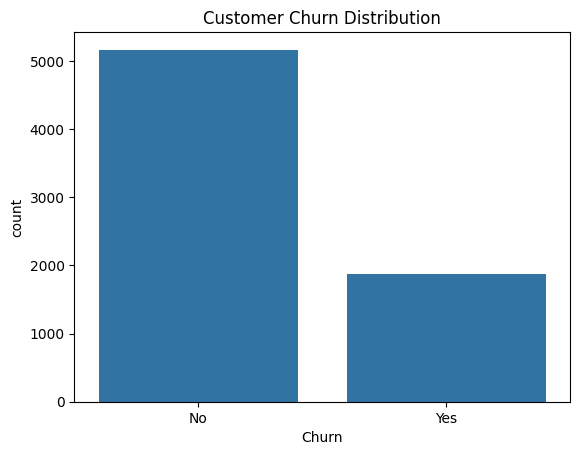

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

This plot shows the number of customers who stayed and customers who churned. We can see that the No class is larger than the Yes class.

###***4.6 Contract Type vs Churn***

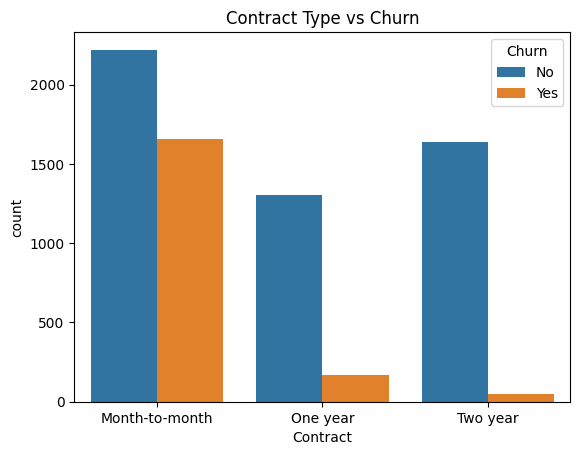

In [19]:
sns.countplot(x = "Contract" , hue = "Churn" , data = df)
plt.title("Contract Type vs Churn")
plt.show()

This plot compares customer churn across different contract types. It helps us see whether contract duration is related to customer churn.

###***4.7 Tenure vs Churn***

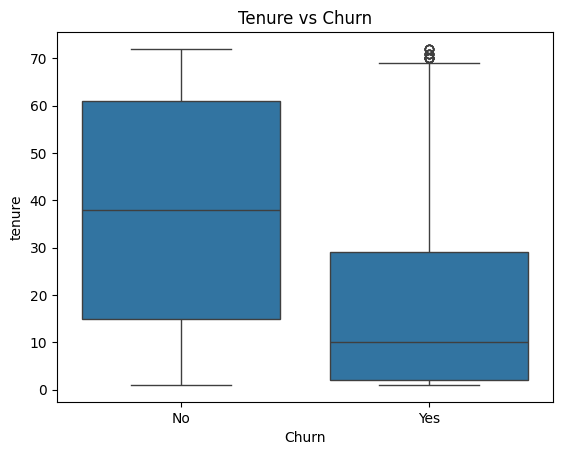

In [20]:
sns.boxplot(x = "Churn" , y = "tenure" , data =df)
plt.title("Tenure vs Churn")
plt.show()

###***4.8 Monthly Charges vs Churn***

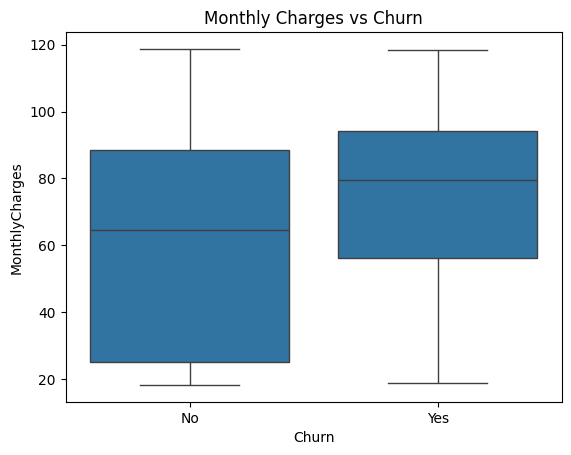

In [21]:
sns.boxplot(x = "Churn" , y = "MonthlyCharges" , data =df)
plt.title("Monthly Charges vs Churn")
plt.show()

This plot compares monthly charges between customers who churned and customers who stayed. It helps identify whether higher monthly charges are associated with churn.Monthly charges are different because customers use different services and plans. Customers with more or more expensive services usually pay more.

###***4.9 Correlation Analysis***

In [22]:
numeric_df = df.select_dtypes(include = ["int64" ,"float64"])
numeric_df.corr()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


##**5. Preprocessing**

###***5.1 Split Features and Target***

In [27]:
df["Churn_num"]=df["Churn"].map({"Yes":1 , "No":0})

/tmp/ipykernel_888/1426493154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Churn_num"]=df["Churn"].map({"Yes":1 , "No":0})


In [36]:
X = df.drop(columns = ["customerID","Churn" , "Churn_num"])
y = df["Churn_num"]

X contains the input features, while y contains the target variable. We remove Churn and Churn_num from the feature set because they represent the target.

###***5.2 Train-Test Split***

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X , y ,test_size = 0.2 ,random_state= 42 , stratify=y)

The dataset is split into training and testing sets. We use 80% of the data for training and 20% for testing.

stratify=y keeps approximately the same churn class proportion in both the training and testing sets.

###***5.3 Separate Numerical and Categorical Features***

In [38]:
numerical_features= X.select_dtypes(include = ["int64" , "float64"]).columns
categorical_features = X.select_dtypes(include = "object").columns

This code separates numerical and categorical features because they require different preprocessing steps.

###***5.4 Create Preprocessing Pipeline***

In [39]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
preprosser = ColumnTransformer([
   ("num" , StandardScaler() , numerical_features),
   ("cat" , OneHotEncoder() , categorical_features)
])

Numerical features are standardized using StandardScaler, while categorical features are converted into numerical form using one-hot encoding.

StandardScaler transforms numerical values so that they have approximately mean 0 and standard deviation 1.

###***5.5 Fit Preprocessing on Training Data Only***

In [40]:
X_train_processed = preprosser.fit_transform(X_train)
X_test_processed = preprosser.transform(X_test)

The preprocessing is fitted only on the training data and then applied to the test data. This prevents data leakage.

##**6. Training**

###***6.1 Logistic Regression — Baseline***

In [41]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter = 100)
log_model.fit(X_train_processed , y_train)

LogisticRegression()

Logistic Regression is used as a baseline classification model. It estimates the probability that a customer belongs to the churn class.

The model first calculates a linear score and then uses the sigmoid function to convert this score into a probability between 0 and 1.

###***6.2 Logistic Regression with L2 Regularization***

In [42]:
log_reg_model = LogisticRegression(
    C=0.5,
    penalty="l2",
    max_iter=1000
)

log_reg_model.fit(X_train_processed, y_train)

LogisticRegression(C=0.5, max_iter=1000)

This model uses L2 regularization to reduce very large coefficients and make the model less sensitive to individual features.

The parameter C controls the strength of regularization. A smaller C means stronger regularization, while a larger C means weaker regularization.

###***6.3 Decision Tree Classifier***

In [43]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Decision Tree is a non-linear classification model. It makes predictions by splitting the data using a sequence of yes-or-no rules based on feature values.

max_depth=5 limits the size of the tree and helps reduce overfitting.

##**7. Evaluation**

###***7.1 Predictions***

In [44]:
y_pred_log = log_model.predict(X_test_processed)
y_pred_reg = log_reg_model.predict(X_test_processed)
y_pred_tree = tree_model.predict(X_test_processed)

This code uses each trained model to predict whether customers in the test set will churn or stay.

###***7.2 Confusion Matrix — Logistic Regression***

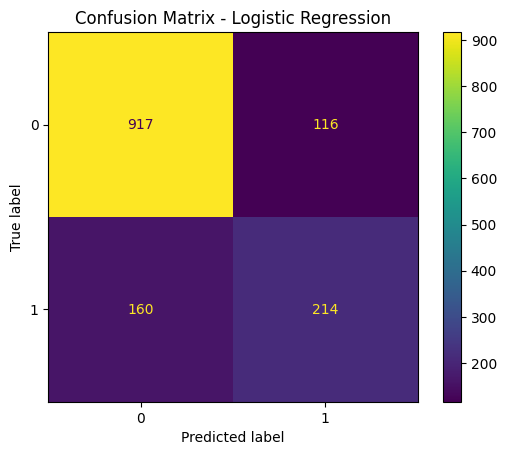

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The Logistic Regression model correctly predicted 917 non-churn customers and 214 churn customers. It produced 116 false positives and 160 false negatives. False negatives are especially important in this business problem because they represent customers who actually churned but were not identified by the model.

###***7.3 Comparison Table***

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": log_model,
    "Logistic Regression L2": log_reg_model,
    "Decision Tree": tree_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append([
        name,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1", "ROC-AUC"]
)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.648485,0.572193,0.607955,0.835929
1,Logistic Regression L2,0.648318,0.566845,0.604850,0.835976
2,Decision Tree,0.602094,0.614973,0.608466,0.829625


The Decision Tree achieved the highest Recall of about 0.615, which means it identified the largest proportion of actual churners. This is important for our business objective because False Negatives are more costly than False Positives. However, Logistic Regression achieved higher Precision and slightly higher ROC-AUC.

###***7.4 ROC Curve***

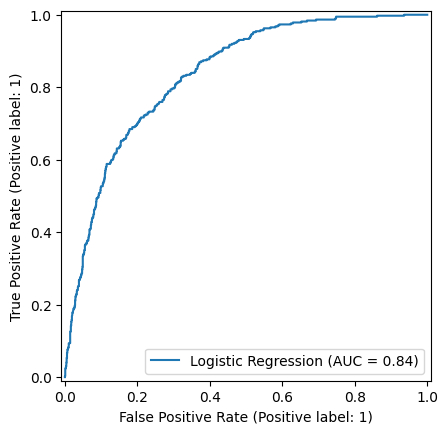

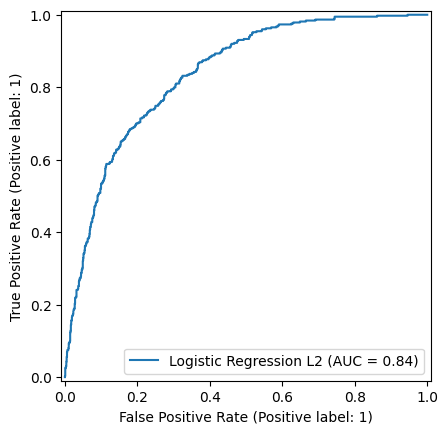

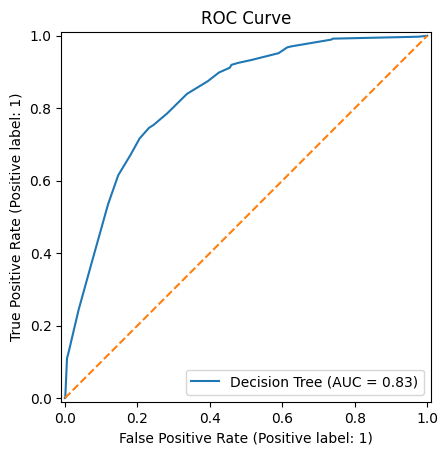

In [47]:
from sklearn.metrics import RocCurveDisplay

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test_processed,
        y_test,
        name=name
    )

plt.plot([0, 1], [0, 1], "--")
plt.title("ROC Curve")
plt.show()

The ROC curves show that all three models perform better than random guessing. Logistic Regression and Logistic Regression with L2 regularization achieved the highest ROC-AUC of approximately 0.84, while the Decision Tree achieved approximately 0.83.

###***7.5 Precision–Recall Curve***

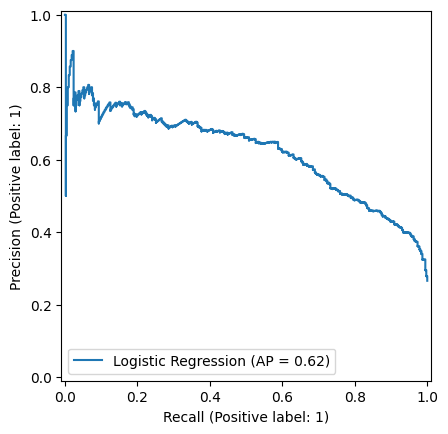

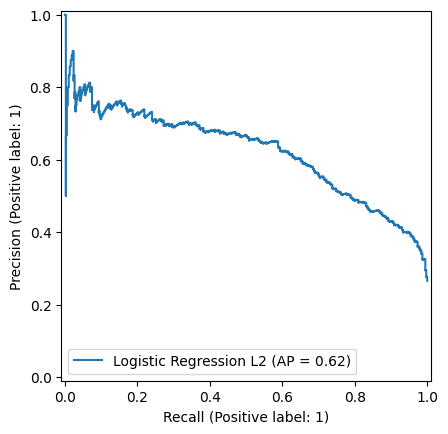

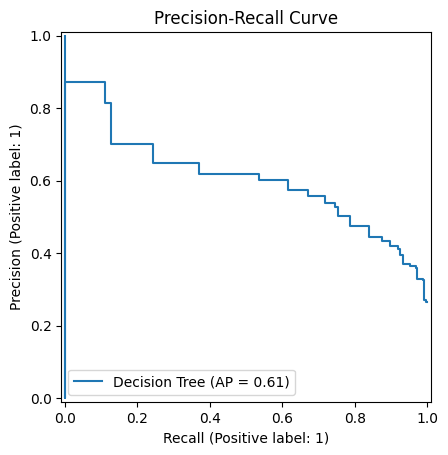

In [48]:
from sklearn.metrics import PrecisionRecallDisplay

for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test_processed,
        y_test,
        name=name
    )

plt.title("Precision-Recall Curve")
plt.show()

The Precision–Recall curves show the trade-off between Precision and Recall at different classification thresholds. Logistic Regression and Logistic Regression with L2 regularization achieved an Average Precision of about 0.62, while the Decision Tree achieved about 0.61. This indicates that the logistic models provide a slightly better overall balance between Precision and Recall.

###***7.6 Try Different Thresholds***

In [49]:
y_prob = log_model.predict_proba(X_test_processed)[:, 1]

thresholds = [0.3, 0.5, 0.7]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    threshold_results.append([
        t,
        precision_score(y_test, y_pred_t),
        recall_score(y_test, y_pred_t)
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall"]
)

threshold_df

,Threshold,Precision,Recall
0,0.3,0.510791,0.759358
1,0.5,0.648485,0.572193
2,0.7,0.759036,0.168449


At a threshold of 0.3, Recall increases to about 0.76, meaning the model identifies more actual churners. However, Precision decreases to about 0.51. At a threshold of 0.7, Precision increases, but Recall drops significantly. Since missing churners is more costly for the business, a lower threshold such as 0.3 may be more appropriate.

###***7.7 Best Model for Business***

For this business problem, the Logistic Regression model with a threshold of 0.3 is the most suitable choice because it achieves a high Recall of about 0.76.

This means the model can identify around 76% of actual churners. Although Precision decreases to about 0.51, this trade-off is acceptable because False Negatives are more costly than False Positives in this case.

A False Negative means that a customer who will actually leave is missed by the model. Therefore, prioritizing Recall helps the company identify more at-risk customers and take retention actions earlier.

###**8. Conclusion**

**Best Model:**

For this business problem, Logistic Regression with a threshold of 0.3 is the most suitable option. At this threshold, the model achieved a Recall of approximately 0.76, which means it identified about 76% of the customers who actually churned.

**Key Findings:**

Customers with shorter tenure and higher monthly charges were more likely to churn. Customers with month-to-month contracts also showed higher churn compared with customers on longer contracts.

The standard Logistic Regression achieved a ROC-AUC of about 0.84, while the Decision Tree achieved the highest Recall at the default threshold of 0.5. However, lowering the Logistic Regression threshold to 0.3 increased Recall from about 0.57 to 0.76, which better matches the business objective.

**Success Criteria:**

The main success criterion was high Recall because False Negatives are more costly than False Positives. This criterion was reasonably met by using Logistic Regression with a lower classification threshold.

**Limitations:**

The dataset represents a fictional telecom company, so the results may not fully represent real-world telecom customers. Also, the dataset contains limited information about customer behavior and does not include factors such as customer satisfaction history or competitor offers.

###**9. References**

The dataset was obtained from Kaggle and is based on IBM Telco Customer Churn sample data. It represents a fictional telecommunications company. The dataset contains customer demographic information, service usage, contract details, monthly charges, and churn status.